Simple Linear Regression -> MAE: 30.20, MSE: 1367.58, RMSE: 36.98, R2: 0.9085
Multiple Linear Regression -> MAE: 12.70, MSE: 219.39, RMSE: 14.81, R2: 0.9853
Gradient Descent Linear Regression -> MAE: 12.70, MSE: 219.39, RMSE: 14.81, R2: 0.9853


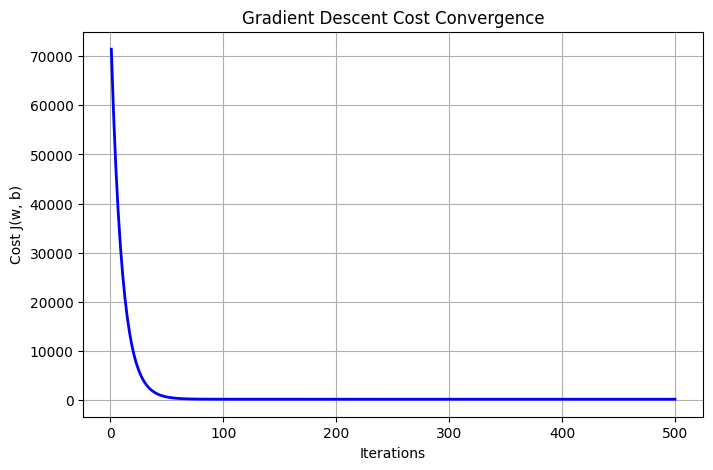

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Load Dataset
df = pd.read_csv('house_prices_expanded_dataset-v2.csv')

# Define Features (X) and Target (y)
X = df[['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years']]
y = df['Price_1000s']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- PART 1: Scikit-Learn Models ---
# Simple Linear Regression
slr = LinearRegression()
slr.fit(X_train[['Area_sqft']], y_train)
y_pred_slr = slr.predict(X_test[['Area_sqft']])

# Multiple Linear Regression
mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)

def print_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}")

print_metrics("Simple Linear Regression", y_test, y_pred_slr)
print_metrics("Multiple Linear Regression", y_test, y_pred_mlr)

# --- PART 2: Custom Gradient Descent Optimization ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

class GradientDescentLinearRegression:
    def __init__(self, learning_rate=0.05, iterations=500):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        y_vec = y.values if isinstance(y, pd.Series) else y

        for _ in range(self.iterations):
            y_pred = np.dot(X, self.weights) + self.bias

            # Compute Cost (MSE / 2)
            cost = (1 / (2 * n_samples)) * np.sum((y_pred - y_vec) ** 2)
            self.cost_history.append(cost)

            # Compute Gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y_vec))
            db = (1 / n_samples) * np.sum(y_pred - y_vec)

            # Update Parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Instantiate and run Gradient Descent
gd_model = GradientDescentLinearRegression(learning_rate=0.05, iterations=500)
gd_model.fit(X_train_scaled, y_train)
y_pred_gd = gd_model.predict(X_test_scaled)

print_metrics("Gradient Descent Linear Regression", y_test, y_pred_gd)

# Plot Cost Function Convergence
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(gd_model.cost_history) + 1), gd_model.cost_history, color='blue', linewidth=2)
plt.title('Gradient Descent Cost Convergence')
plt.xlabel('Iterations')
plt.ylabel('Cost J(w, b)')
plt.grid(True)
plt.savefig('cost_convergence.png')
plt.show()